In [1]:
##### This code preps the 30x30 prioritization rasters to overlay with capital and labor maps

import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.warp import reproject
from rasterio.enums import Resampling
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

In [2]:
##### Load data

# Get the current working directory
cd = Path.cwd().parent 

# priority rasters
biodiversity_with_PA = f"{cd}/Data/Raw/Jung_priority_areas/BiodiversityOnly/10km/minshort_speciestargets_biome.id_withPA_esh10km_repruns10_ranked.tif"
all_with_PA = f"{cd}/Data/Raw/Jung_priority_areas/BiodiversityCarbonWater/10km/minshort_speciestargets_biome.id_withPA_carbon__water__esh10km_repruns10_ranked.tif"

# save paths
biodiversity_with_PA_path = f"{cd}/Data/Clean/Priority_areas/biodiversity_with_PA.tif"
all_with_PA_path = f"{cd}/Data/Clean/Priority_areas/all_with_PA.tif"


In [3]:
##### Create raster identifying top 30%
# 0 = no in top 30%, 1 = in top 30%, not PA, 2 = in top 30%, already PA

def reclassify_PA_raster(in_path):
    with rasterio.open(in_path) as src:
        data = src.read(1)
        nodata = src.nodata
        profile = src.profile.copy()

    # Start with a copy so nodata pixels can be preserved
    reclass = np.full_like(data, fill_value=0 if nodata is None else nodata)

    # Apply reclassification rules
    reclass = np.where((data >= 16) & (data <= 85), 0, reclass)
    reclass = np.where((data >= 86) & (data <= 100), 1, reclass)
    reclass = np.where((data >= 0) & (data <= 15), 2, reclass)

    # Preserve nodata explicitly (so it doesn't get swept into one of the classes above)
    if nodata is not None:
        reclass = np.where(data == nodata, nodata, reclass)

    profile.update(dtype=reclass.dtype, nodata=nodata)

    return reclass, profile, nodata

# ensures that if a pixel as marked as already a PA in one, its marked as that in the other 
# because there is some slight (0.01%) difference across the 2
def align_reclassifications(biodiversity_reclass, all_reclass, all_nodata):
    aligned_all = all_reclass.copy()

    # If biodiversity says 2 -> force all to 2
    aligned_all = np.where(biodiversity_reclass == 2, 2, aligned_all)

    # If all was 2 but biodiversity is not 2 -> demote all to 1
    aligned_all = np.where((all_reclass == 2) & (biodiversity_reclass != 2), 1, aligned_all)

    # Preserve nodata explicitly in case either step stepped on it
    if all_nodata is not None:
        aligned_all = np.where(all_reclass == all_nodata, all_nodata, aligned_all)

    return aligned_all


def save_raster(reclass, profile, out_path):
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(reclass, 1)

def reclassify_no_PA_raster(in_path, out_path, with_PA_reclass_path):
    with rasterio.open(in_path) as src:
        data = src.read(1)
        nodata = src.nodata
        profile = src.profile.copy()

    # Read the already-reclassified with_PA raster to find pixels already flagged as PA (2)
    with rasterio.open(with_PA_reclass_path) as pa_src:
        pa_data = pa_src.read(1)

    # Start with a copy so nodata pixels can be preserved
    reclass = np.full_like(data, fill_value=0 if nodata is None else nodata)

    # Apply reclassification rules
    reclass = np.where((data >= 0) & (data <= 85), 0, reclass)
    reclass = np.where((data >= 71) & (data <= 100), 1, reclass)

    # Where the with_PA raster already flags a pixel as PA (2), force it to 2 here too
    reclass = np.where(pa_data == 2, 2, reclass)

    # Preserve nodata explicitly (so it doesn't get swept into one of the classes above)
    if nodata is not None:
        reclass = np.where(data == nodata, nodata, reclass)

    profile.update(dtype=reclass.dtype, nodata=nodata)

    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(reclass, 1)


# --- Reclassify both, align, then save ---
biodiversity_reclass, biodiversity_profile, _ = reclassify_PA_raster(biodiversity_with_PA)
all_reclass, all_profile, all_nodata = reclassify_PA_raster(all_with_PA)

all_reclass = align_reclassifications(biodiversity_reclass, all_reclass, all_nodata)

save_raster(biodiversity_reclass, biodiversity_profile, biodiversity_with_PA_path)
save_raster(all_reclass, all_profile, all_with_PA_path)

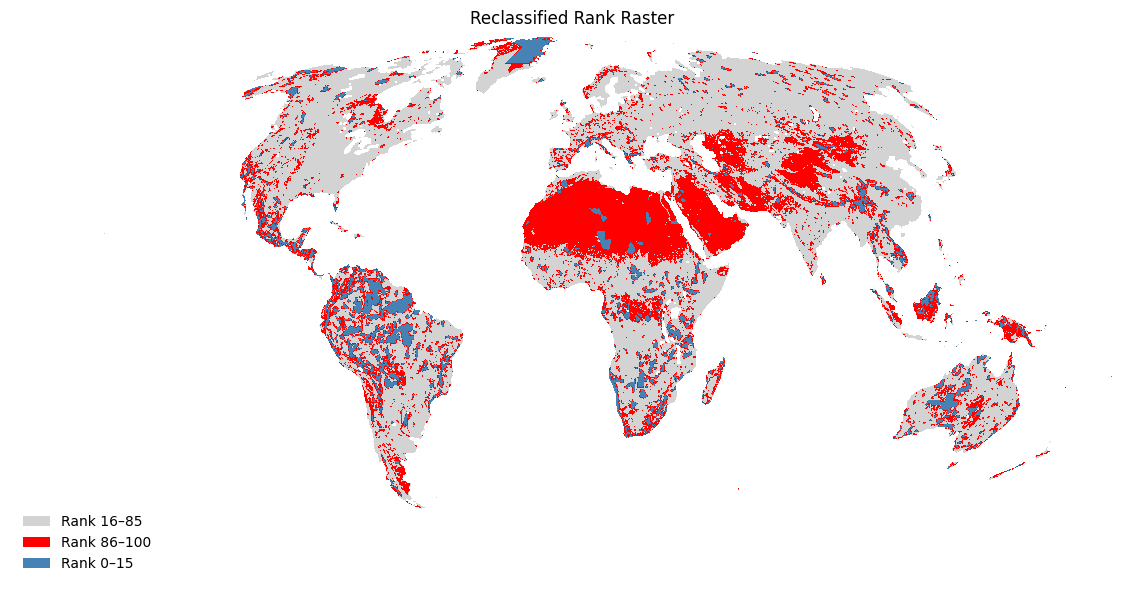

In [4]:
with rasterio.open(all_with_PA_path) as src:
    data = src.read(1).astype(float)
    nodata = src.nodata

# Mask nodata so it renders transparent
data_masked = np.where(data == nodata, np.nan, data)

# Colors: 0 = grey (middle 16-85), 1 = red (top 86-100), 2 = blue (bottom 0-15)
cmap = ListedColormap(["lightgrey", "red", "steelblue"])
cmap.set_bad(color="none")  # nodata -> transparent
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(data_masked, cmap=cmap, norm=norm)
ax.axis("off")
ax.set_title("Reclassified Rank Raster")

legend_elements = [
    Patch(facecolor="lightgrey", label="Rank 16–85"),
    Patch(facecolor="red", label="Rank 86–100"),
    Patch(facecolor="steelblue", label="Rank 0–15"),
]
ax.legend(handles=legend_elements, loc="lower left", frameon=False)

plt.tight_layout()
plt.show()